# 02 · Trajectory Complexity (movement)

For every trial, and for each of its three segments (**whole trial**, **outbound**,
**inbound**), compute the trajectory-complexity metrics natively in `movement`, on the
**body centroid** (the mean of all keypoints):

| metric | `movement` function | meaning |
|---|---|---|
| path length | `compute_path_length` | total distance travelled (px) |
| straightness | `compute_path_straightness` | beeline / path length, $D/L \in (0, 1]$; 1 = perfectly straight |
| directional change | `compute_directional_change` | total absolute heading change along the path (deg) |
| path deviation | `compute_path_deviation` | mean distance from the straight start→end line (px) |

Then we look at how these distribute, split by outcome (Success / Fail / Miss).

> **Kernel:** repo `.venv`. Run `01_summary_table.ipynb` first (this notebook reads the
> summary table it saves).

## 0 · Setup and config

Same config block as notebook 01 (so the same sessions are found), then load the saved
summary table and re-list the sessions to reach their pose on disk.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

WORKSPACE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(WORKSPACE) not in sys.path:
    sys.path.insert(0, str(WORKSPACE))

# Package = data pull + formatting only.
from pose_trajectory import workspace
from pose_trajectory.loading import select_pose_sessions, session_movement_dataset
from data_conduit.utils.utils_core import exclude  # 'all but these' selector

# movement = the analysis. Every metric below is one of these calls.
from movement.filtering import filter_by_confidence
from movement.kinematics import (
    compute_directional_change,
    compute_path_deviation,
    compute_path_length,
    compute_path_straightness,
)

pd.set_option("display.max_columns", 30)
warnings.filterwarnings("ignore")

In [2]:
# ============================== EDIT THESE (match notebook 01) ==============================
DATA_ROOT = workspace.REPO_ROOT / "datasets" / "firstdata" / "BonsaiFiles"
MICE     = ["FbR_M01569522"]   # include list | exclude("X", ...) for all-but | None = all
DAYS     = ["Day 11"]          # exact day-folder names (note "Day 11" and "Day_11" both exist)
SESSIONS = None                # session-folder names to include, or None for all

CONFIDENCE_MIN = 0.9     # blank DLC detections below this likelihood before measuring
MIN_STEP_LENGTH = 3.0    # ignore centroid steps shorter than this (px) when measuring directional
                         # change, so sub-pixel jitter while the animal is still is not counted as turning
# ===========================================================================================

sessions = select_pose_sessions(DATA_ROOT, mice=MICE, days=DAYS, sessions=SESSIONS, require_dlc=True)

# These notebooks write per-mouse outputs, so resolve the single selected mouse for the
# summary-table lookup and the output filenames. Select exactly one mouse above.
_mice = sorted({entry["mouse"] for entry in sessions.values()})
assert len(_mice) == 1, f"Select exactly one mouse for this notebook; selection has {_mice}"
MOUSE_ID = _mice[0]

# The per-trial reference table built by notebook 01.
summary = pd.read_csv(workspace.OUTPUT_DIR / f"summary_table_{MOUSE_ID}.csv")
print(f"{len(summary)} trials | {len(sessions)} sessions")

109 trials | 6 sessions


## 1 · The segments, and a per-segment complexity helper

Each trial has three segments, defined by the summary table's time columns. We slice the
centroid track to a segment's `[start, end]` window with `centroid.sel(time=slice(...))`
(pose and events share one clock, so the seconds line up) and call the four `movement`
functions. `path_length` and `straightness` return one value per trajectory; `directional
change` and `deviation` return a per-frame series, which we reduce to a total turn and a
mean deviation respectively.

In [3]:
# segment name -> (start column, end column) in the summary table
SEGMENTS = {
    "whole":    ("outbound_start", "inbound_end"),
    "outbound": ("outbound_start", "outbound_end"),
    "inbound":  ("inbound_start",  "inbound_end"),
}


def segment_complexity(centroid, t0, t1, *, min_step_length=MIN_STEP_LENGTH):
    """Four movement complexity metrics for the centroid between t0 and t1 (seconds)."""
    # Need a valid window and at least two frames to define a path.
    if not np.isfinite([t0, t1]).all():
        return dict(path_length=np.nan, straightness=np.nan,
                    directional_change_deg=np.nan, path_deviation_px=np.nan, n_frames=0)
    seg = centroid.sel(time=slice(t0, t1))
    n = int(seg.sizes["time"])
    if n < 2:
        return dict(path_length=np.nan, straightness=np.nan,
                    directional_change_deg=np.nan, path_deviation_px=np.nan, n_frames=n)
    # movement calls. directional change is per-step (summed to a total absolute turn);
    # min_step_length suppresses heading noise from near-stationary frames. deviation is
    # per-frame (averaged to a mean distance off the straight start->end line).
    dc = compute_directional_change(seg, in_degrees=True, min_step_length=min_step_length)
    dev = compute_path_deviation(seg)
    return dict(
        path_length=float(compute_path_length(seg).values.squeeze()),
        straightness=float(compute_path_straightness(seg).values.squeeze()),
        directional_change_deg=float(np.nansum(np.abs(dc.values))),
        path_deviation_px=float(np.nanmean(dev.values)),
        n_frames=n,
    )

## 2 · Compute the metrics for every trial and segment

For each session we read its pose once, blank low-confidence detections with `movement`'s
`filter_by_confidence`, and take the body centroid (`clean.mean('keypoints')`). Then we
walk that session's trials and segments, building one tidy row per (trial, segment).

In [4]:
records = []
for key, entry in sessions.items():
    # Pose for this session, formatted for movement by the package.
    mov = session_movement_dataset(entry["path"])
    # movement: blank low-confidence detections, then reduce keypoints to the centroid.
    clean = filter_by_confidence(mov["position"], mov["confidence"], threshold=CONFIDENCE_MIN, print_report=False)
    centroid = clean.mean("keypoint")   # one point per frame: the body centroid

    # This session's trials, from the summary table.
    for _, trow in summary[summary["session"] == key].iterrows():
        for seg_name, (c0, c1) in SEGMENTS.items():
            metrics_row = segment_complexity(centroid, trow[c0], trow[c1])
            records.append({
                "session": key, "day": trow["day"],
                "trial_in_session": trow["trial_in_session"], "trial_in_day": trow["trial_in_day"],
                "result": trow["result"], "segment": seg_name, **metrics_row,
            })

complexity = pd.DataFrame.from_records(records)
print("rows:", len(complexity), "(trials x 3 segments)")
complexity.head(9)

rows: 327 (trials x 3 segments)


,session,day,trial_in_session,trial_in_day,result,segment,path_length,straightness,directional_change_deg,path_deviation_px,n_frames
0,2026-04-08T14-53-51,Day 11,1,1,Success,whole,345.741472,0.000850,17464.199737,10.301818,199
1,2026-04-08T14-53-51,Day 11,1,1,Success,outbound,321.971072,0.026079,17464.199737,11.306044,125
2,2026-04-08T14-53-51,Day 11,1,1,Success,inbound,21.124198,0.261875,0.000000,0.307043,74
3,2026-04-08T14-53-51,Day 11,2,2,Success,whole,411.561936,0.030062,49430.421598,7.825966,387
4,2026-04-08T14-53-51,Day 11,2,2,Success,outbound,320.334166,0.131205,34122.049613,7.507341,325
5,2026-04-08T14-53-51,Day 11,2,2,Success,inbound,89.900953,0.358700,15308.371986,2.155818,62
6,2026-04-08T14-53-51,Day 11,3,3,Success,whole,395.868011,0.018855,38596.202798,7.524155,315
7,2026-04-08T14-53-51,Day 11,3,3,Success,outbound,342.941714,0.061886,23791.607784,12.467980,267
8,2026-04-08T14-53-51,Day 11,3,3,Success,inbound,51.774632,0.309873,14804.595014,0.750084,48


## 3 · Distributions, split by outcome (Success / Fail / Miss)

A 4×3 grid: one row per metric, one column per segment. Each panel shows the distribution
across trials with a box, and every trial as a jittered point coloured by outcome, so the
Success / Fail / Miss split is visible even when Fails and Misses are rare.

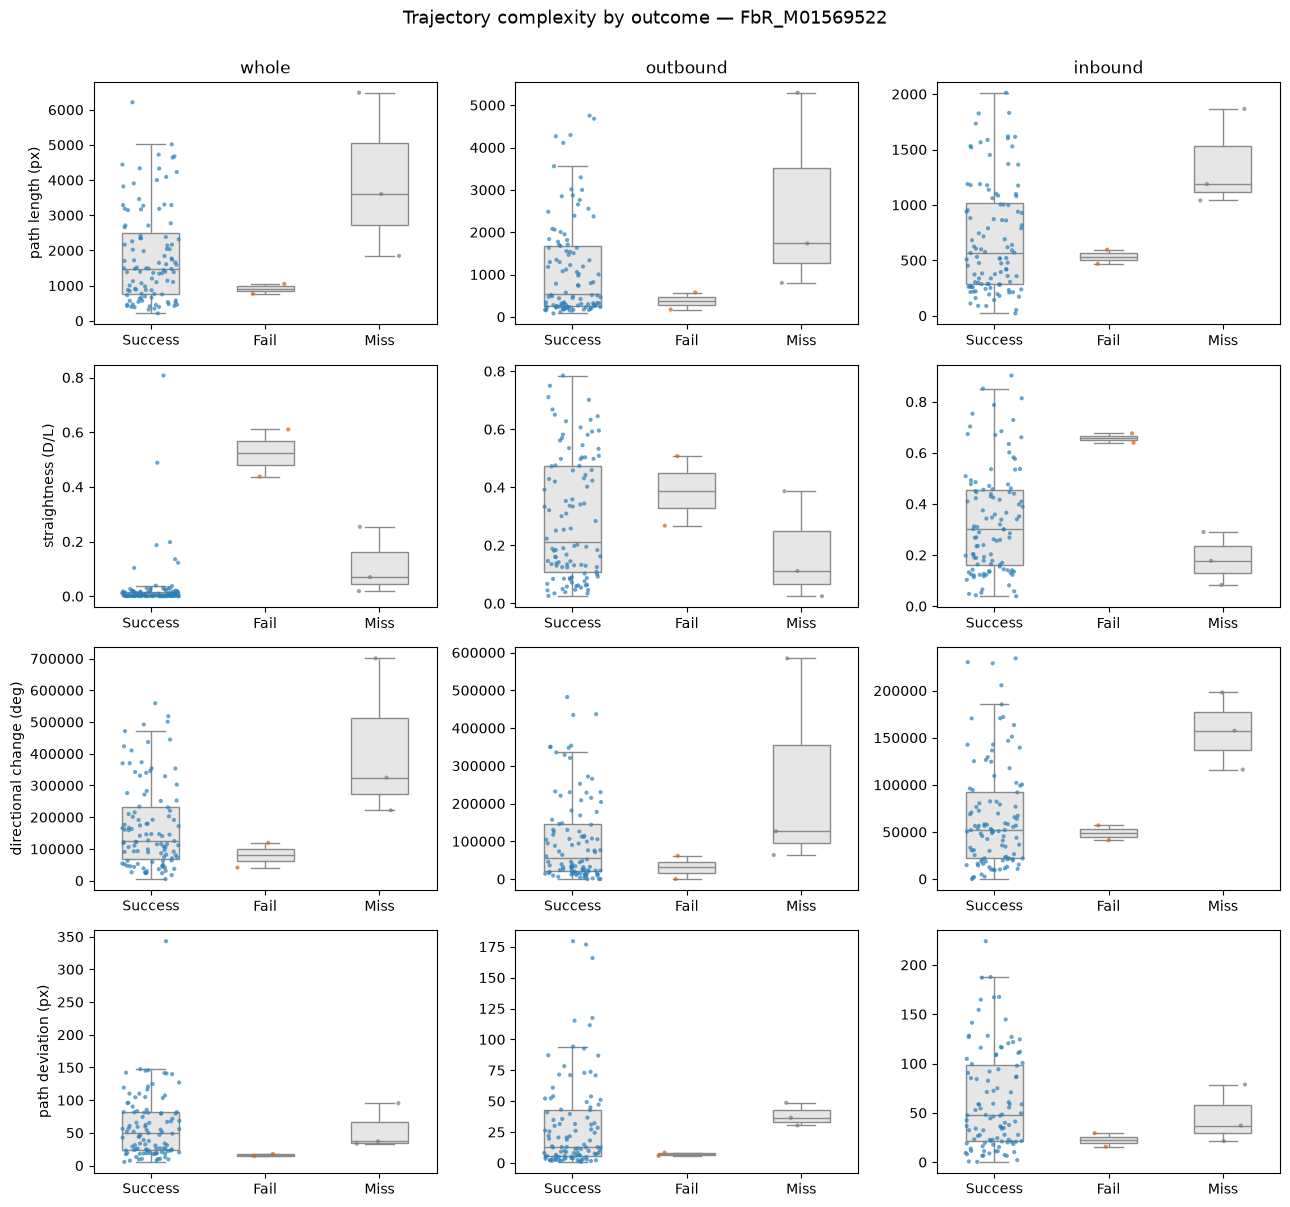

In [5]:
SEG_ORDER = ["whole", "outbound", "inbound"]
RESULT_ORDER = ["Success", "Fail", "Miss"]
PALETTE = {"Success": "#2c7fb8", "Fail": "#d95f0e", "Miss": "#7a7a7a"}


def distribution_grid(df, metric_labels, title, fname):
    """Grid of metric (rows) x segment (cols) distributions, split by outcome.

    A box for the spread plus a jittered point per trial coloured by outcome. NaNs are
    dropped per panel and only outcome categories that actually have data are drawn, so
    rare Fail/Miss outcomes never break the plot.
    """
    fig, axes = plt.subplots(len(metric_labels), len(SEG_ORDER),
                             figsize=(13, 3 * len(metric_labels)), squeeze=False)
    for r, (metric, label) in enumerate(metric_labels.items()):
        for c, seg in enumerate(SEG_ORDER):
            ax = axes[r][c]
            sub = df[df["segment"] == seg].dropna(subset=[metric])
            present = [res for res in RESULT_ORDER if (sub["result"] == res).any()]
            if present:
                sns.boxplot(data=sub, x="result", y=metric, order=present, ax=ax,
                            showfliers=False, width=0.5, color="0.9")
                sns.stripplot(data=sub, x="result", y=metric, order=present, ax=ax,
                              hue="result", palette=PALETTE, legend=False, size=3, jitter=0.25, alpha=0.7)
            ax.set_xlabel("")
            ax.set_ylabel(label if c == 0 else "")
            if r == 0:
                ax.set_title(seg)
    fig.suptitle(title, y=1.002, fontsize=13)
    fig.tight_layout()
    workspace.save_figure(fig, fname)
    plt.show()


METRIC_LABELS = {
    "path_length": "path length (px)",
    "straightness": "straightness (D/L)",
    "directional_change_deg": "directional change (deg)",
    "path_deviation_px": "path deviation (px)",
}
distribution_grid(complexity, METRIC_LABELS, f"Trajectory complexity by outcome — {MOUSE_ID}", f"trajectory_complexity_{MOUSE_ID}")

## 4 · Save the metrics table

Stored under `outputs/` for downstream use or combining across mice.

In [6]:
out_path = workspace.OUTPUT_DIR / f"trajectory_complexity_{MOUSE_ID}.csv"
complexity.to_csv(out_path, index=False)
print("saved:", out_path)

saved: /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Pose_Trajectory_Analysis/outputs/trajectory_complexity_FbR_M01569522.csv
